# GROUP PRACTICAL ASSIGNMENT: GEOMETRIC TRANSFORMATIONS
**Course:** DCSC 62205: Geometric Modeling  
**Group:** 3  
**Topic:** Matrix Representation, 2D and 3D Transformations Using Python

In [1]:
# ============================================================
# IMPORT ALL REQUIRED LIBRARIES
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import requests
import os

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## PART A: Polygon Transformations (2D)

In [2]:
# ============================================================
# TASK 1: Define polygon points A(2,2), B(5,2), C(6,4), D(3,6), E(1,4)
# ============================================================

# Define polygon vertices as a 2xN matrix (x-row, y-row)
# Each column is one point: [A, B, C, D, E]
poly_pts = np.array([[2, 5, 6, 3, 1],   # x-coordinates
                     [2, 2, 4, 6, 4]])  # y-coordinates

# Homogeneous form (3xN) for 2D matrix transformations
ones = np.ones((1, poly_pts.shape[1]))
poly_h = np.vstack([poly_pts, ones])  # 3 x 5

labels = ['A(2,2)', 'B(5,2)', 'C(6,4)', 'D(3,6)', 'E(1,4)']

print('Polygon vertices defined:')
for i, lbl in enumerate(labels):
    print(f'  {lbl}')
print('\nCoordinate matrix (2 x 5):')
print(poly_pts)
print('\nHomogeneous matrix (3 x 5):')
print(poly_h)

Polygon vertices defined:
  A(2,2)
  B(5,2)
  C(6,4)
  D(3,6)
  E(1,4)

Coordinate matrix (2 x 5):
[[2 5 6 3 1]
 [2 2 4 6 4]]

Homogeneous matrix (3 x 5):
[[2. 5. 6. 3. 1.]
 [2. 2. 4. 6. 4.]
 [1. 1. 1. 1. 1.]]


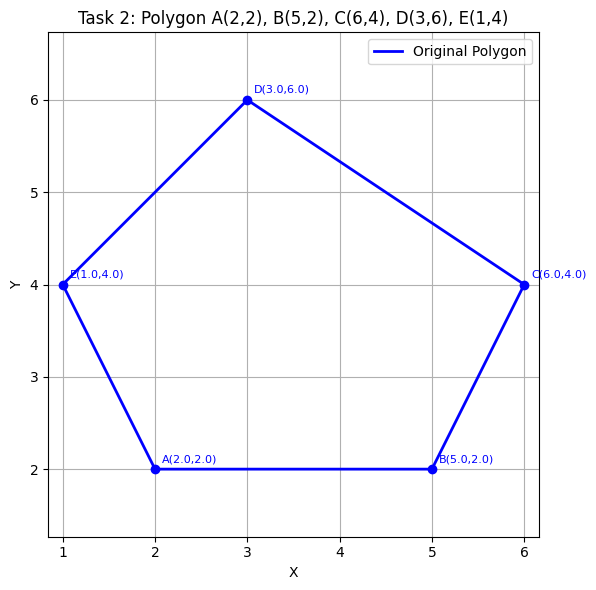

In [3]:
# ============================================================
# TASK 2: Plot the polygon using Matplotlib
# ============================================================

def plot_polygon(pts, color='blue', label='Polygon', linestyle='-', ax=None):
    """Plot a closed polygon from a 2xN array of points."""
    target = ax if ax else plt
    xs = np.append(pts[0], pts[0][0])  # close polygon
    ys = np.append(pts[1], pts[1][0])
    target.plot(xs, ys, color=color, linestyle=linestyle, linewidth=2, label=label)
    # Label vertices
    vertex_labels = ['A', 'B', 'C', 'D', 'E']
    for i in range(pts.shape[1]):
        target.annotate(
            f"{vertex_labels[i]}({pts[0,i]:.1f},{pts[1,i]:.1f})",
            (pts[0,i], pts[1,i]),
            textcoords='offset points', xytext=(5, 5),
            fontsize=8, color=color
        )

plt.figure(figsize=(6, 6))
plot_polygon(poly_pts, color='blue', label='Original Polygon')
plt.scatter(poly_pts[0], poly_pts[1], color='blue', zorder=5)
plt.title('Task 2: Polygon A(2,2), B(5,2), C(6,4), D(3,6), E(1,4)')
plt.xlabel('X'); plt.ylabel('Y')
plt.grid(True); plt.legend(); plt.axis('equal')
plt.tight_layout(); plt.show()

Translation Matrix (tx=-2, ty=3):
[[ 1  0 -2]
 [ 0  1  3]
 [ 0  0  1]]

Translated points:
[[ 0.  3.  4.  1. -1.]
 [ 5.  5.  7.  9.  7.]]


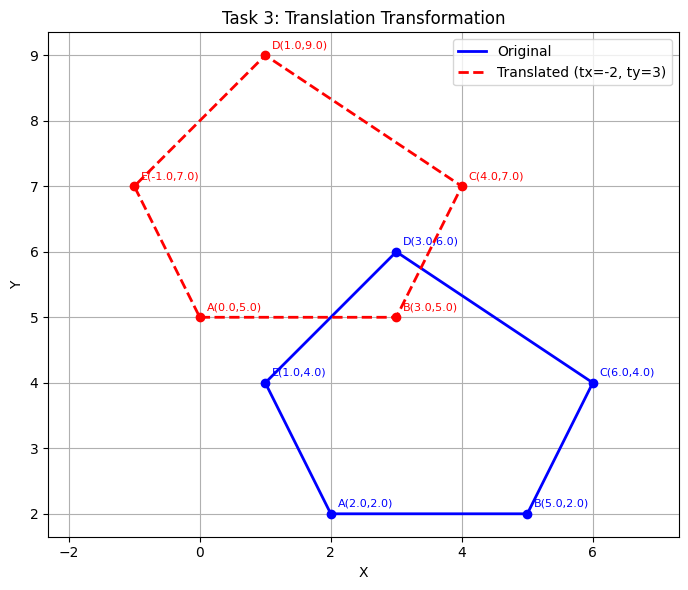

In [4]:
# ============================================================
# TASK 3: Apply translation (tx = -2, ty = 3)
# ============================================================

tx, ty = -2, 3

T_translate = np.array([[1, 0, tx],
                         [0, 1, ty],
                         [0, 0,  1]])

poly_translated = (T_translate @ poly_h)[:2]

print(f'Translation Matrix (tx={tx}, ty={ty}):')
print(T_translate)
print('\nTranslated points:')
print(poly_translated)

plt.figure(figsize=(7, 6))
plot_polygon(poly_pts,        color='blue', label='Original')
plot_polygon(poly_translated, color='red',  label=f'Translated (tx={tx}, ty={ty})', linestyle='--')
plt.scatter(poly_pts[0], poly_pts[1], color='blue', zorder=5)
plt.scatter(poly_translated[0], poly_translated[1], color='red', zorder=5)
plt.title('Task 3: Translation Transformation'); plt.xlabel('X'); plt.ylabel('Y')
plt.grid(True); plt.legend(); plt.axis('equal'); plt.tight_layout(); plt.show()

Scaling Matrix (Sx=1.2, Sy=1.2):
[[1.2 0.  0. ]
 [0.  1.2 0. ]
 [0.  0.  1. ]]

Scaled points:
[[2.4 6.  7.2 3.6 1.2]
 [2.4 2.4 4.8 7.2 4.8]]


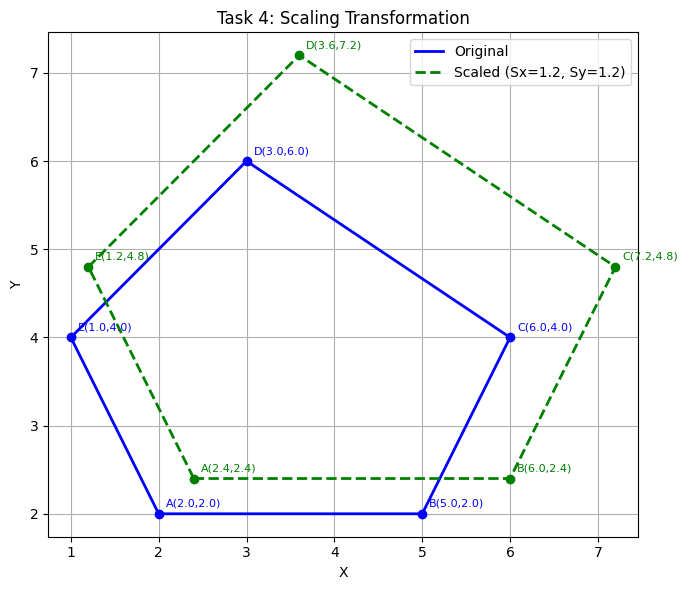

In [5]:
# ============================================================
# TASK 4: Apply scaling transformation (Sx=1.2, Sy=1.2)
# ============================================================

Sx, Sy = 1.2, 1.2

T_scale = np.array([[Sx, 0,  0],
                     [0,  Sy, 0],
                     [0,  0,  1]])

poly_scaled = (T_scale @ poly_h)[:2]

print(f'Scaling Matrix (Sx={Sx}, Sy={Sy}):')
print(T_scale)
print('\nScaled points:')
print(poly_scaled)

plt.figure(figsize=(7, 6))
plot_polygon(poly_pts,    color='blue',  label='Original')
plot_polygon(poly_scaled, color='green', label=f'Scaled (Sx={Sx}, Sy={Sy})', linestyle='--')
plt.scatter(poly_pts[0], poly_pts[1], color='blue', zorder=5)
plt.scatter(poly_scaled[0], poly_scaled[1], color='green', zorder=5)
plt.title('Task 4: Scaling Transformation'); plt.xlabel('X'); plt.ylabel('Y')
plt.grid(True); plt.legend(); plt.axis('equal'); plt.tight_layout(); plt.show()

Rotation Matrix (30° CCW about origin):
[[ 0.866 -0.5    0.   ]
 [ 0.5    0.866  0.   ]
 [ 0.     0.     1.   ]]

Rotated points:
[[ 0.7321  3.3301  3.1962 -0.4019 -1.134 ]
 [ 2.7321  4.2321  6.4641  6.6962  3.9641]]


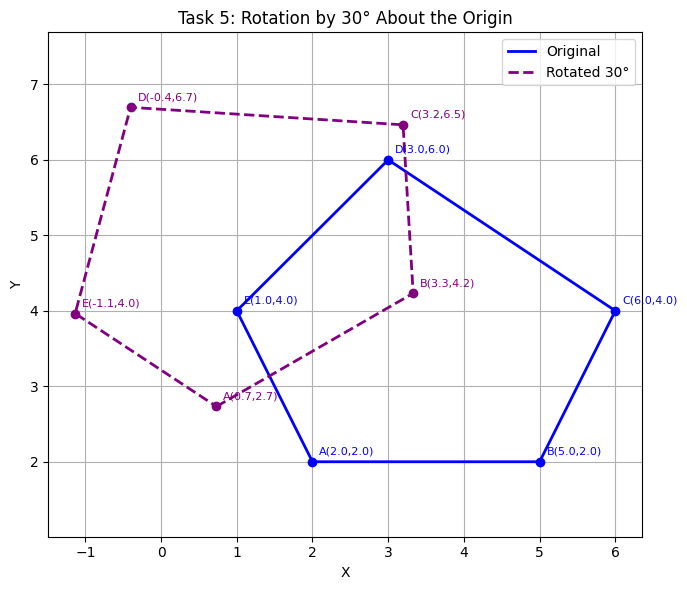

In [6]:
# ============================================================
# TASK 5: Rotate the polygon by 30° about the origin
# ============================================================

theta = np.radians(30)

T_rotate = np.array([[np.cos(theta), -np.sin(theta), 0],
                      [np.sin(theta),  np.cos(theta), 0],
                      [0,              0,             1]])

poly_rotated = (T_rotate @ poly_h)[:2]

print('Rotation Matrix (30° CCW about origin):')
print(np.round(T_rotate, 4))
print('\nRotated points:')
print(np.round(poly_rotated, 4))

plt.figure(figsize=(7, 6))
plot_polygon(poly_pts,    color='blue',   label='Original')
plot_polygon(poly_rotated, color='purple', label='Rotated 30°', linestyle='--')
plt.scatter(poly_pts[0], poly_pts[1], color='blue', zorder=5)
plt.scatter(poly_rotated[0], poly_rotated[1], color='purple', zorder=5)
plt.title('Task 5: Rotation by 30° About the Origin'); plt.xlabel('X'); plt.ylabel('Y')
plt.grid(True); plt.legend(); plt.axis('equal'); plt.tight_layout(); plt.show()

Reflection Matrix (across y = x):
[[0 1 0]
 [1 0 0]
 [0 0 1]]

Reflected points:
[[2. 2. 4. 6. 4.]
 [2. 5. 6. 3. 1.]]


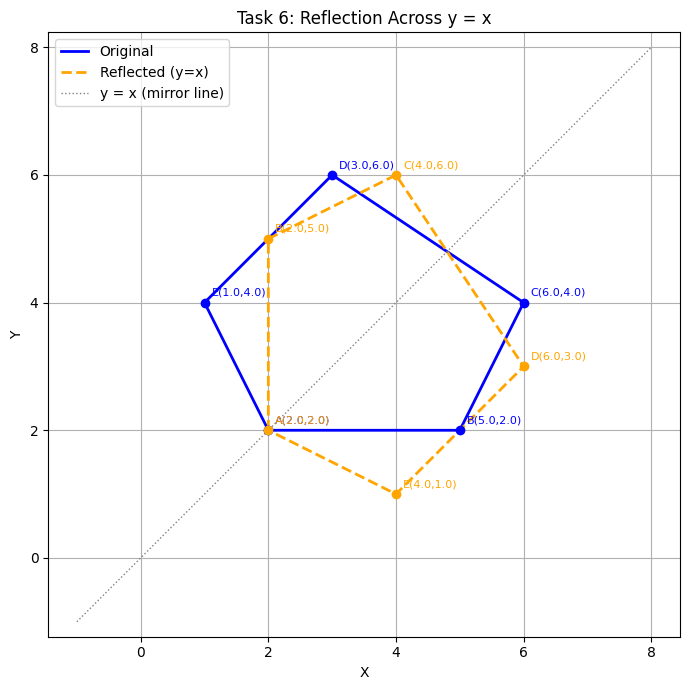

In [7]:
# ============================================================
# TASK 6: Reflect the polygon across the line y = x
# ============================================================

# Reflection across y=x: swap x and y coordinates
T_reflect_yx = np.array([[0, 1, 0],
                           [1, 0, 0],
                           [0, 0, 1]])

poly_reflected = (T_reflect_yx @ poly_h)[:2]

print('Reflection Matrix (across y = x):')
print(T_reflect_yx)
print('\nReflected points:')
print(poly_reflected)

# Plot the line y=x for reference
x_line = np.linspace(-1, 8, 100)

plt.figure(figsize=(7, 7))
plot_polygon(poly_pts,      color='blue',   label='Original')
plot_polygon(poly_reflected, color='orange', label='Reflected (y=x)', linestyle='--')
plt.plot(x_line, x_line, 'gray', linestyle=':', linewidth=1, label='y = x (mirror line)')
plt.scatter(poly_pts[0], poly_pts[1], color='blue', zorder=5)
plt.scatter(poly_reflected[0], poly_reflected[1], color='orange', zorder=5)
plt.title('Task 6: Reflection Across y = x'); plt.xlabel('X'); plt.ylabel('Y')
plt.grid(True); plt.legend(); plt.axis('equal'); plt.tight_layout(); plt.show()

Shear Matrix (x-axis, shx=0.5):
[[1.  0.5 0. ]
 [0.  1.  0. ]
 [0.  0.  1. ]]

Sheared points:
[[3. 6. 8. 6. 3.]
 [2. 2. 4. 6. 4.]]


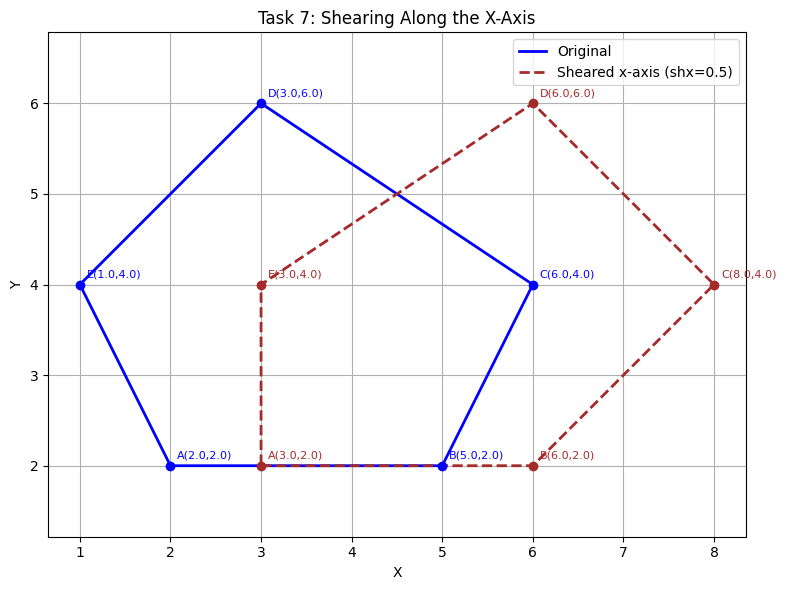

In [8]:
# ============================================================
# TASK 7: Apply shearing along the x-axis
# ============================================================

# X-direction shear: x' = x + shx*y,  y' = y
shx = 0.5

T_shear_x = np.array([[1, shx, 0],
                        [0, 1,   0],
                        [0, 0,   1]])

poly_sheared = (T_shear_x @ poly_h)[:2]

print(f'Shear Matrix (x-axis, shx={shx}):')
print(T_shear_x)
print('\nSheared points:')
print(poly_sheared)

plt.figure(figsize=(8, 6))
plot_polygon(poly_pts,    color='blue',  label='Original')
plot_polygon(poly_sheared, color='brown', label=f'Sheared x-axis (shx={shx})', linestyle='--')
plt.scatter(poly_pts[0], poly_pts[1], color='blue', zorder=5)
plt.scatter(poly_sheared[0], poly_sheared[1], color='brown', zorder=5)
plt.title('Task 7: Shearing Along the X-Axis'); plt.xlabel('X'); plt.ylabel('Y')
plt.grid(True); plt.legend(); plt.axis('equal'); plt.tight_layout(); plt.show()

Projection Matrix (onto y-axis):
[[0 0 0]
 [0 1 0]
 [0 0 1]]

Projected points (all x=0):
[[0. 0. 0. 0. 0.]
 [2. 2. 4. 6. 4.]]


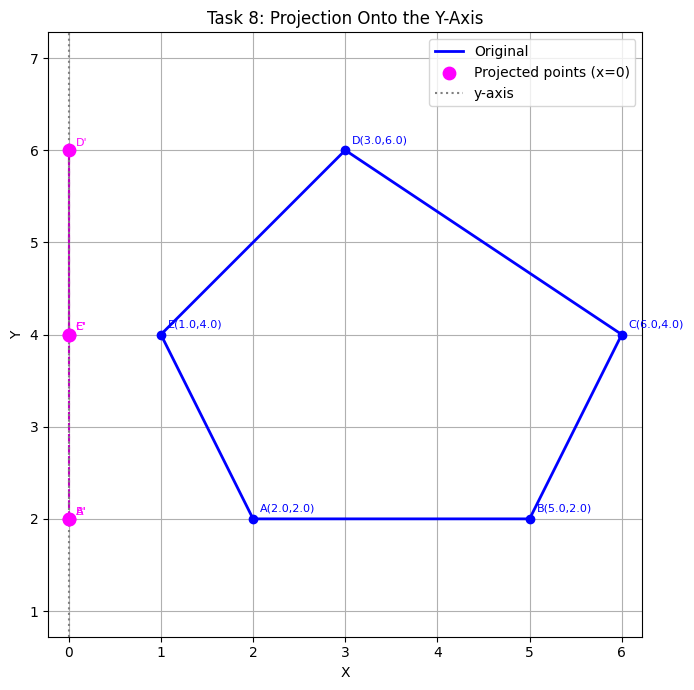

In [9]:
# ============================================================
# TASK 8: Project the polygon onto the y-axis
# ============================================================

# Projection onto y-axis: set x=0, keep y
T_proj_y = np.array([[0, 0, 0],
                      [0, 1, 0],
                      [0, 0, 1]])

poly_projected = (T_proj_y @ poly_h)[:2]

print('Projection Matrix (onto y-axis):')
print(T_proj_y)
print('\nProjected points (all x=0):')
print(poly_projected)

plt.figure(figsize=(7, 7))
plot_polygon(poly_pts, color='blue', label='Original')
plt.scatter(poly_pts[0], poly_pts[1], color='blue', zorder=5)
# Projected points are on y-axis
plt.scatter(poly_projected[0], poly_projected[1], color='magenta', zorder=6, s=80,
            label='Projected points (x=0)')
plt.plot(poly_projected[0], poly_projected[1], 'm--', linewidth=1.5)
# Label projected points
for i, name in enumerate(['A\'','B\'','C\'','D\'','E\'']):
    plt.annotate(name, (poly_projected[0,i], poly_projected[1,i]),
                 textcoords='offset points', xytext=(5,3), color='magenta', fontsize=8)
plt.axvline(x=0, color='gray', linestyle=':', label='y-axis')
plt.title('Task 8: Projection Onto the Y-Axis'); plt.xlabel('X'); plt.ylabel('Y')
plt.grid(True); plt.legend(); plt.axis('equal'); plt.tight_layout(); plt.show()

Composite Transformation Matrix (Translate → Rotate → Scale):
[[ 1.0392 -0.6    -3.8785]
 [ 0.6     1.0392  1.9177]
 [ 0.      0.      1.    ]]

Composite result points:
[[-3.      0.1177 -0.0431 -4.3608 -5.2392]
 [ 5.1962  6.9962  9.6746  9.9531  6.6746]]


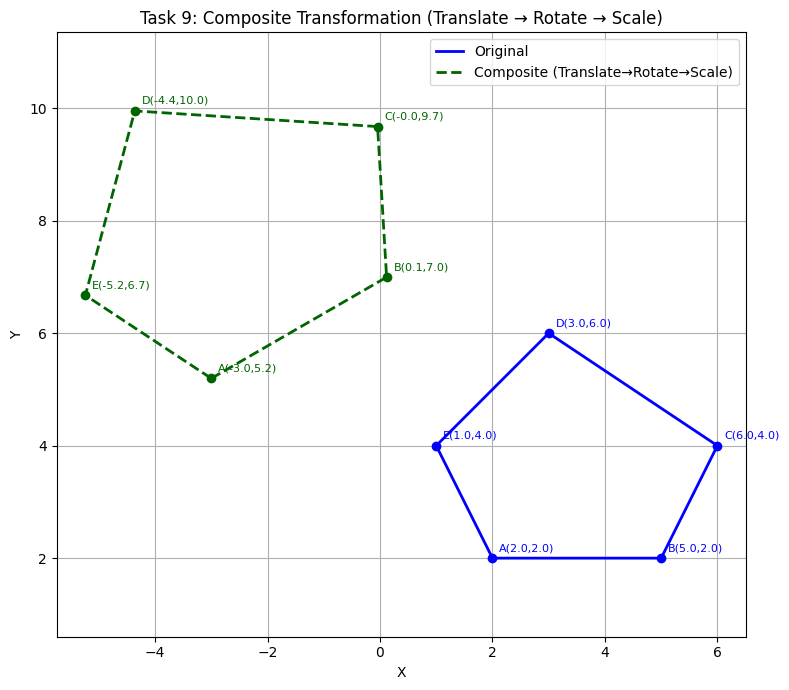

In [10]:
# ============================================================
# TASK 9: Composite transformation (translate → rotate → scale)
# ============================================================

# Step 1: Translate (tx=-2, ty=3)
# Step 2: Rotate 30°
# Step 3: Scale (Sx=1.2, Sy=1.2)
# Composite = T_scale @ T_rotate @ T_translate  (applied right to left)

T_composite = T_scale @ T_rotate @ T_translate

poly_composite = (T_composite @ poly_h)[:2]

print('Composite Transformation Matrix (Translate → Rotate → Scale):')
print(np.round(T_composite, 4))
print('\nComposite result points:')
print(np.round(poly_composite, 4))

plt.figure(figsize=(8, 7))
plot_polygon(poly_pts,       color='blue',      label='Original')
plot_polygon(poly_composite, color='darkgreen', label='Composite (Translate→Rotate→Scale)', linestyle='--')
plt.scatter(poly_pts[0], poly_pts[1], color='blue', zorder=5)
plt.scatter(poly_composite[0], poly_composite[1], color='darkgreen', zorder=5)
plt.title('Task 9: Composite Transformation (Translate → Rotate → Scale)')
plt.xlabel('X'); plt.ylabel('Y')
plt.grid(True); plt.legend(); plt.axis('equal'); plt.tight_layout(); plt.show()

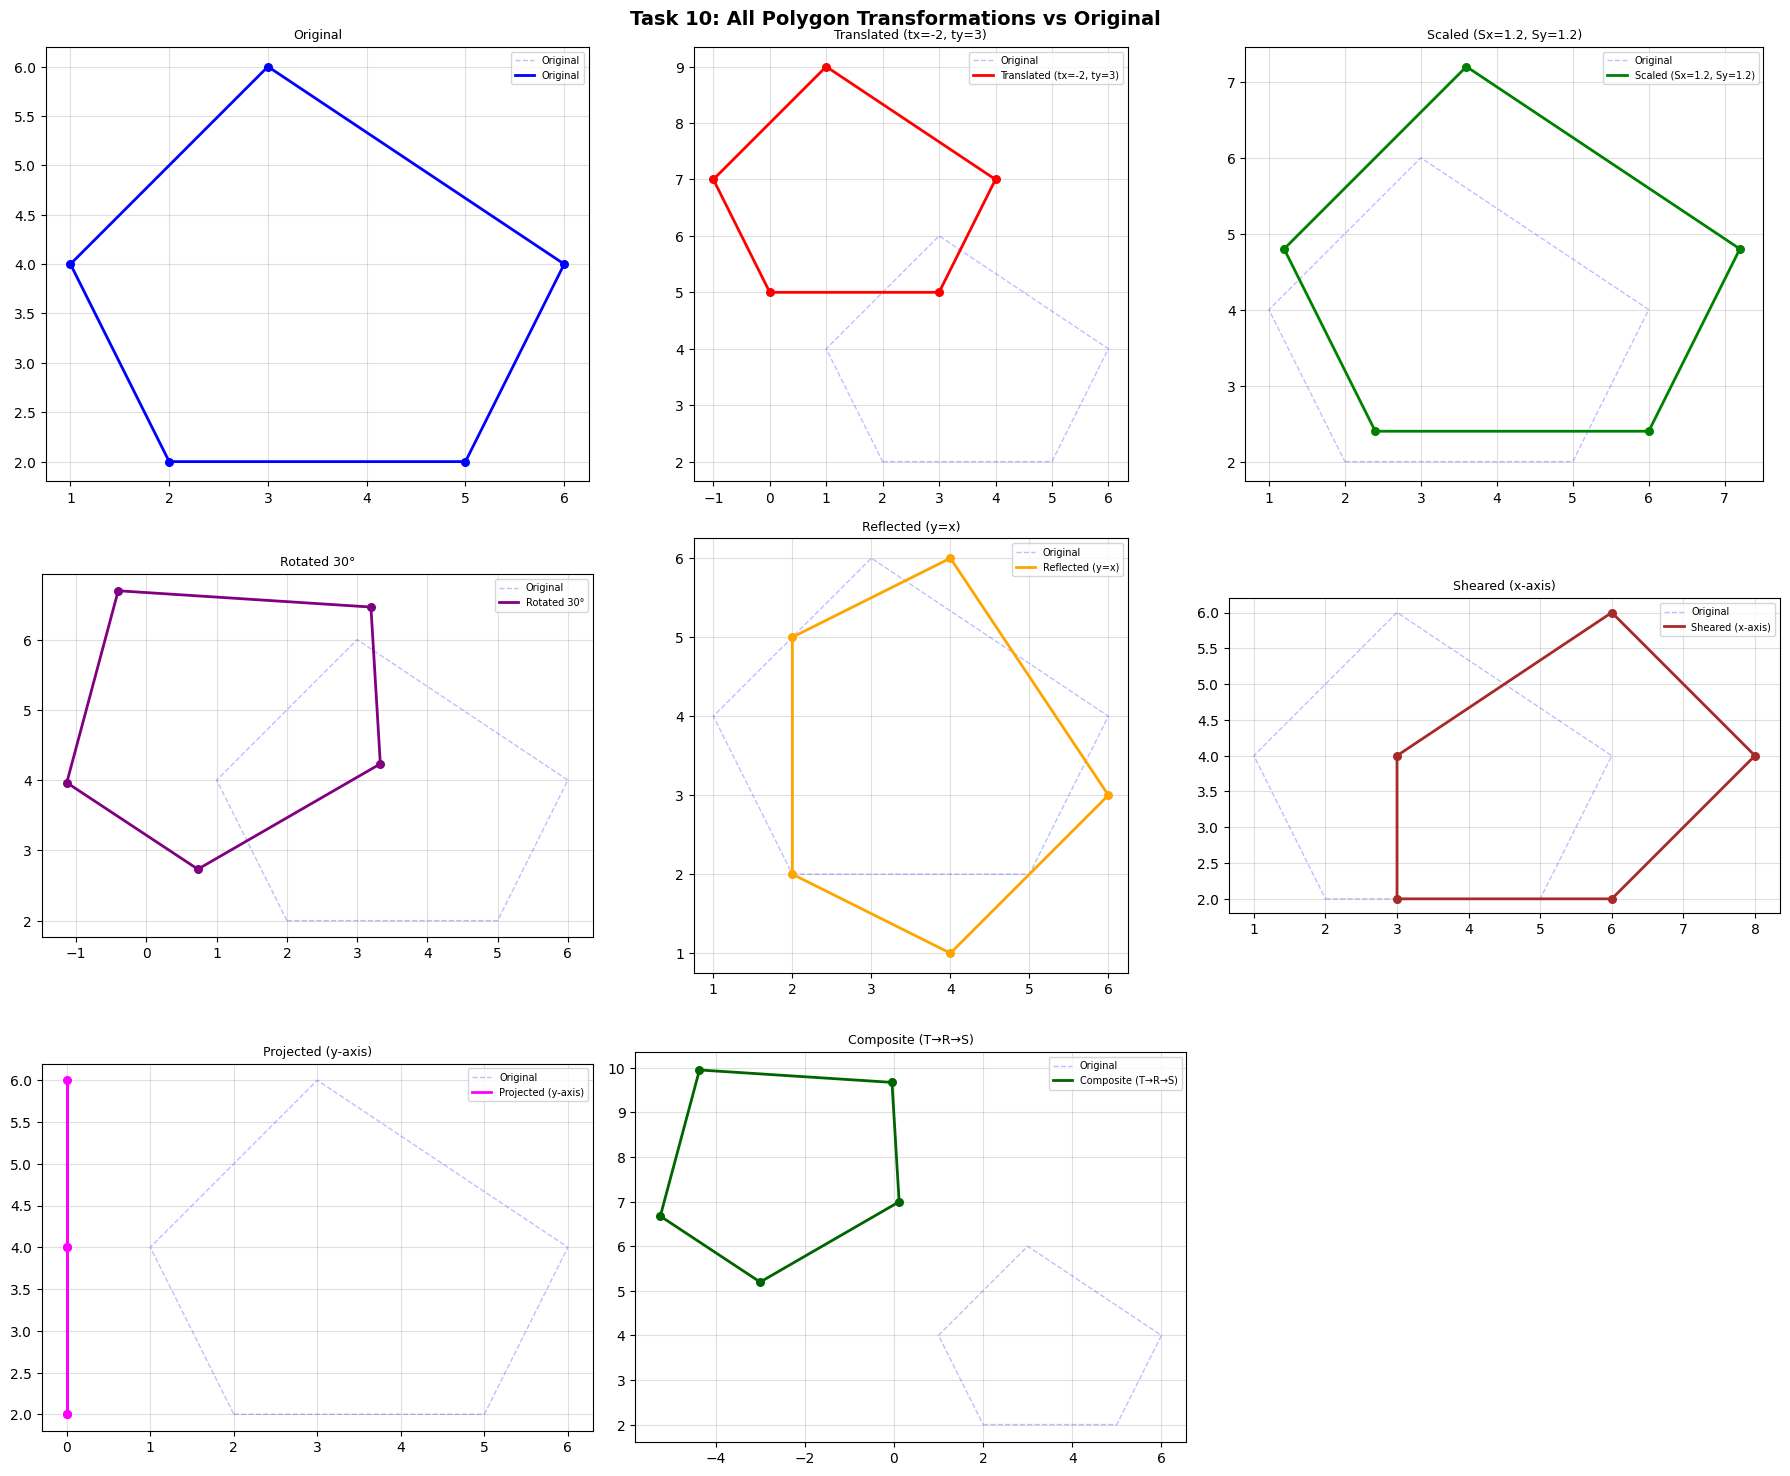

In [11]:
# ============================================================
# TASK 10: Plot all transformations and compare with original
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Task 10: All Polygon Transformations vs Original', fontsize=14, fontweight='bold')

all_transforms = [
    (poly_pts,        'blue',      'Original'),
    (poly_translated, 'red',       'Translated (tx=-2, ty=3)'),
    (poly_scaled,     'green',     'Scaled (Sx=1.2, Sy=1.2)'),
    (poly_rotated,    'purple',    'Rotated 30°'),
    (poly_reflected,  'orange',    'Reflected (y=x)'),
    (poly_sheared,    'brown',     'Sheared (x-axis)'),
    (poly_projected,  'magenta',   'Projected (y-axis)'),
    (poly_composite,  'darkgreen', 'Composite (T→R→S)'),
]

for idx, (pts, color, title) in enumerate(all_transforms):
    ax = axes.flatten()[idx]
    # Ghost original
    orig_xs = np.append(poly_pts[0], poly_pts[0][0])
    orig_ys = np.append(poly_pts[1], poly_pts[1][0])
    ax.plot(orig_xs, orig_ys, 'b--', alpha=0.25, linewidth=1, label='Original')
    # Transformed
    xs = np.append(pts[0], pts[0][0])
    ys = np.append(pts[1], pts[1][0])
    ax.plot(xs, ys, color=color, linewidth=2, label=title)
    ax.scatter(pts[0], pts[1], color=color, zorder=5, s=30)
    ax.set_title(title, fontsize=9)
    ax.grid(True, alpha=0.4)
    ax.set_aspect('equal')
    ax.legend(fontsize=7)

# Hide the last empty subplot
axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()

---
## PART B: Motion Data — GPS Trajectories
**Dataset:** Geolife GPS Trajectory Dataset  
**Public Link:** https://www.microsoft.com/en-us/research/project/geolife-building-social-networks-using-human-location-history/

In [12]:
# ============================================================
# TASK 11: Load a GPS trajectory file
# We generate synthetic GPS data (similar to Geolife .plt format)
# if the dataset is not locally available.
# ============================================================

print('Dataset: Geolife GPS Trajectory Dataset')
print('Link: https://www.microsoft.com/en-us/research/project/')
print('      geolife-building-social-networks-using-human-location-history/')
print()

# --- Try to load a real Geolife .plt file if available ---
# Geolife .plt format: 6-line header, then rows of:
# latitude, longitude, 0, altitude, days_since_1899, date, time

geolife_path = './Data/Geolife Trajectories 1.3/Data/000/Trajectory/20081023025304.plt'

if os.path.exists(geolife_path):
    data = np.genfromtxt(geolife_path, delimiter=',', skip_header=6)
    gps_lat = data[:, 0]
    gps_lon = data[:, 1]
    gps_alt = data[:, 3]   # altitude in feet
    print(f'Real Geolife file loaded: {len(gps_lat)} points')
else:
    print('Geolife dataset not found locally.')
    print('Generating realistic synthetic GPS trajectory...')
    np.random.seed(42)
    n = 200
    # Simulate a walking/driving path around Beijing area
    t = np.linspace(0, 4 * np.pi, n)
    gps_lat = 39.90 + 0.01 * np.cumsum(np.random.randn(n) * 0.01 + np.sin(t) * 0.002)
    gps_lon = 116.40 + 0.01 * np.cumsum(np.random.randn(n) * 0.01 + np.cos(t) * 0.002)
    gps_alt = 50 + 10 * np.sin(t) + np.random.randn(n) * 2   # altitude in metres
    print(f'Synthetic trajectory created: {n} points')

print(f'Latitude  range: [{gps_lat.min():.5f}, {gps_lat.max():.5f}]')
print(f'Longitude range: [{gps_lon.min():.5f}, {gps_lon.max():.5f}]')
print(f'Altitude  range: [{gps_alt.min():.2f}, {gps_alt.max():.2f}]')

Dataset: Geolife GPS Trajectory Dataset
Link: https://www.microsoft.com/en-us/research/project/
      geolife-building-social-networks-using-human-location-history/

Geolife dataset not found locally.
Generating realistic synthetic GPS trajectory...
Synthetic trajectory created: 200 points
Latitude  range: [39.89866, 39.90050]
Longitude range: [116.40003, 116.40180]
Altitude  range: [35.59, 63.65]


In [13]:
# ============================================================
# TASK 12: Extract longitude and latitude coordinates
# ============================================================

# Stack into a 2 x N matrix  [longitude ; latitude]
gps_2d = np.vstack([gps_lon, gps_lat])   # 2 x N
gps_2d_h = np.vstack([gps_2d, np.ones((1, gps_2d.shape[1]))])  # homogeneous 3 x N

print('GPS 2D coordinate matrix shape:', gps_2d.shape)
print('\nFirst 5 (longitude, latitude) points:')
for i in range(5):
    print(f'  Point {i+1}: lon={gps_2d[0,i]:.6f}, lat={gps_2d[1,i]:.6f}')

GPS 2D coordinate matrix shape: (2, 200)

First 5 (longitude, latitude) points:
  Point 1: lon=116.400056, lat=39.900050
  Point 2: lon=116.400132, lat=39.900037
  Point 3: lon=116.400260, lat=39.900104
  Point 4: lon=116.400385, lat=39.900260
  Point 5: lon=116.400267, lat=39.900242


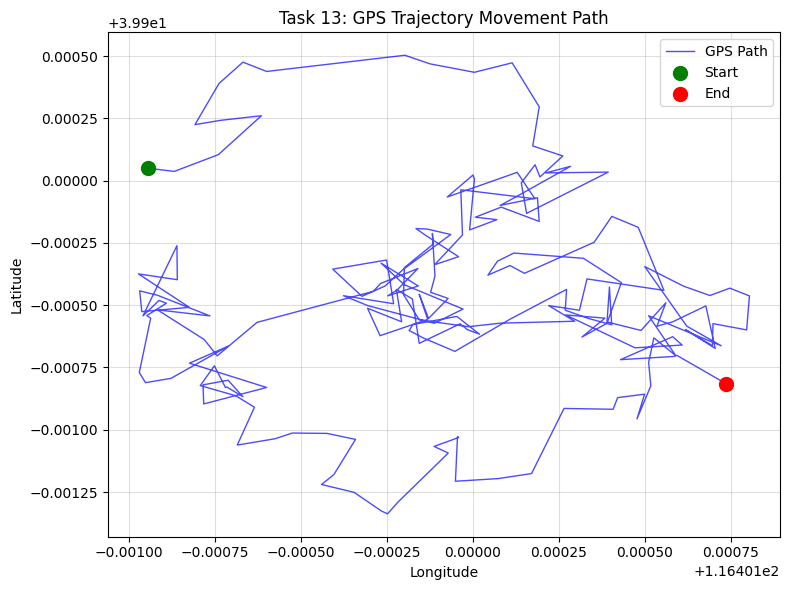

In [14]:
# ============================================================
# TASK 13: Plot the movement path
# ============================================================

plt.figure(figsize=(8, 6))
plt.plot(gps_lon, gps_lat, 'b-', linewidth=1, alpha=0.7, label='GPS Path')
plt.scatter(gps_lon[0],  gps_lat[0],  color='green', s=100, zorder=5, label='Start')
plt.scatter(gps_lon[-1], gps_lat[-1], color='red',   s=100, zorder=5, label='End')
plt.title('Task 13: GPS Trajectory Movement Path')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

Translation: lon+0.02, lat+0.01
Translation Matrix:
[[1.   0.   0.02]
 [0.   1.   0.01]
 [0.   0.   1.  ]]


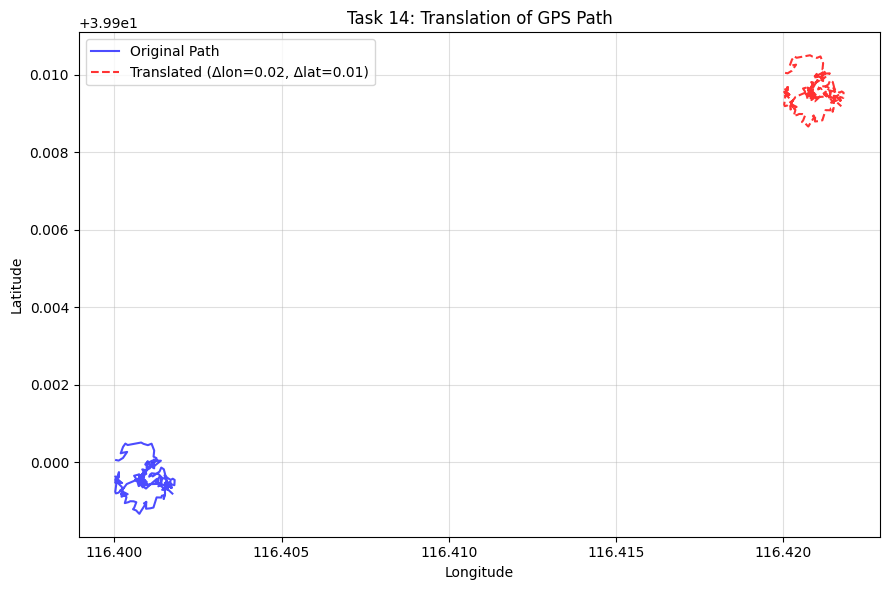

In [15]:
# ============================================================
# TASK 14: Apply translation transformation to shift the path
# ============================================================

# Shift longitude by +0.02, latitude by +0.01
tx_gps, ty_gps = 0.02, 0.01

T_gps_translate = np.array([[1, 0, tx_gps],
                              [0, 1, ty_gps],
                              [0, 0, 1     ]])

gps_translated = (T_gps_translate @ gps_2d_h)[:2]

print(f'Translation: lon+{tx_gps}, lat+{ty_gps}')
print('Translation Matrix:')
print(T_gps_translate)

plt.figure(figsize=(9, 6))
plt.plot(gps_2d[0], gps_2d[1], 'b-',  linewidth=1.5, alpha=0.7, label='Original Path')
plt.plot(gps_translated[0], gps_translated[1], 'r--', linewidth=1.5, alpha=0.8,
         label=f'Translated (Δlon={tx_gps}, Δlat={ty_gps})')
plt.title('Task 14: Translation of GPS Path')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

Rotation angle: 45°
Rotation matrix:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]


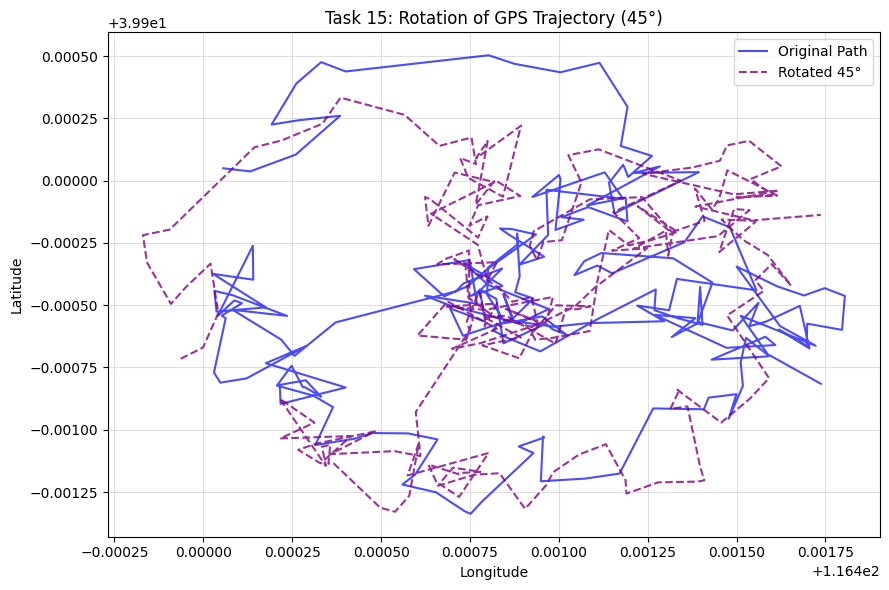

In [16]:
# ============================================================
# TASK 15: Rotate the trajectory by a chosen angle (45°)
# ============================================================

angle = 45
theta_gps = np.radians(angle)

R_gps = np.array([[np.cos(theta_gps), -np.sin(theta_gps)],
                   [np.sin(theta_gps),  np.cos(theta_gps)]])

# Center the data before rotating (rotate around centroid)
centroid = gps_2d.mean(axis=1, keepdims=True)
gps_centered = gps_2d - centroid
gps_rotated = R_gps @ gps_centered + centroid

print(f'Rotation angle: {angle}°')
print('Rotation matrix:')
print(np.round(R_gps, 4))

plt.figure(figsize=(9, 6))
plt.plot(gps_2d[0], gps_2d[1], 'b-',  linewidth=1.5, alpha=0.7, label='Original Path')
plt.plot(gps_rotated[0], gps_rotated[1], 'purple', linestyle='--', linewidth=1.5,
         alpha=0.8, label=f'Rotated {angle}°')
plt.title(f'Task 15: Rotation of GPS Trajectory ({angle}°)')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

Reflection Matrix (across x-axis):
[[ 1  0]
 [ 0 -1]]


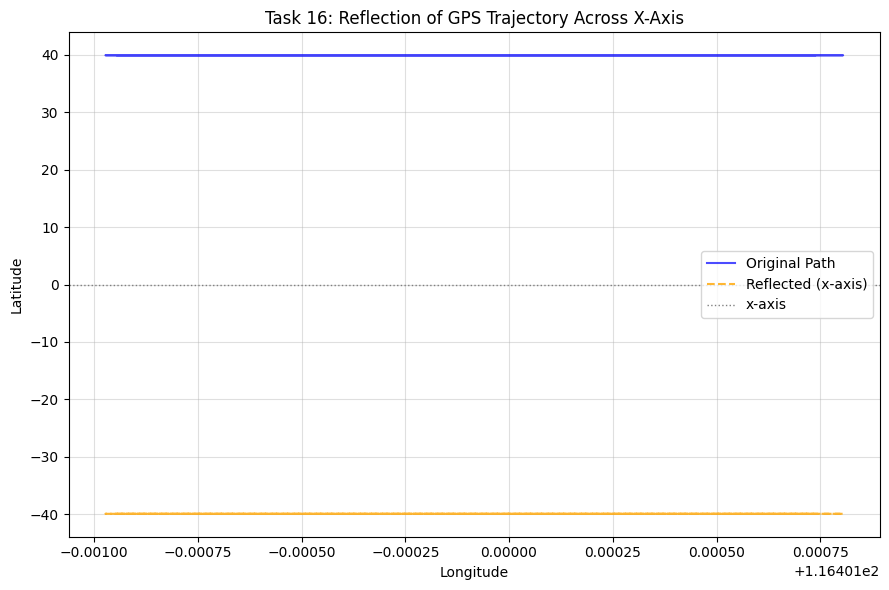

In [17]:
# ============================================================
# TASK 16: Reflect the trajectory across the x-axis
# ============================================================

# Reflection across x-axis: keep longitude (x), negate latitude (y)
R_reflect_x = np.array([[1,  0],
                          [0, -1]])

gps_reflected = R_reflect_x @ gps_2d

print('Reflection Matrix (across x-axis):')
print(R_reflect_x)

plt.figure(figsize=(9, 6))
plt.plot(gps_2d[0],      gps_2d[1],      'b-',  linewidth=1.5, alpha=0.7, label='Original Path')
plt.plot(gps_reflected[0], gps_reflected[1], 'orange', linestyle='--', linewidth=1.5,
         alpha=0.8, label='Reflected (x-axis)')
plt.axhline(y=0, color='gray', linestyle=':', linewidth=1, label='x-axis')
plt.title('Task 16: Reflection of GPS Trajectory Across X-Axis')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

Shear Matrix (x-direction, shx=0.3):
[[1.  0.3]
 [0.  1. ]]


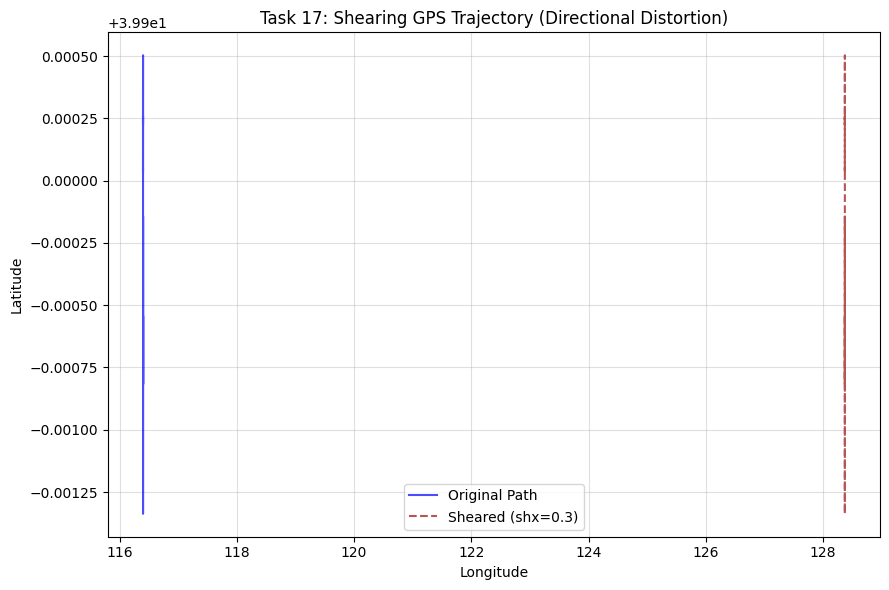

In [18]:
# ============================================================
# TASK 17: Apply shearing to simulate directional distortion
# ============================================================

# Shear in x-direction: simulates lateral wind/directional distortion
shx_gps = 0.3

Sh_gps = np.array([[1, shx_gps],
                    [0, 1      ]])

gps_sheared = Sh_gps @ gps_2d

print(f'Shear Matrix (x-direction, shx={shx_gps}):')
print(Sh_gps)

plt.figure(figsize=(9, 6))
plt.plot(gps_2d[0],     gps_2d[1],     'b-',    linewidth=1.5, alpha=0.7, label='Original Path')
plt.plot(gps_sheared[0], gps_sheared[1], 'brown', linestyle='--', linewidth=1.5,
         alpha=0.8, label=f'Sheared (shx={shx_gps})')
plt.title('Task 17: Shearing GPS Trajectory (Directional Distortion)')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

Projection Matrix (onto longitude axis):
[[1 0]
 [0 0]]


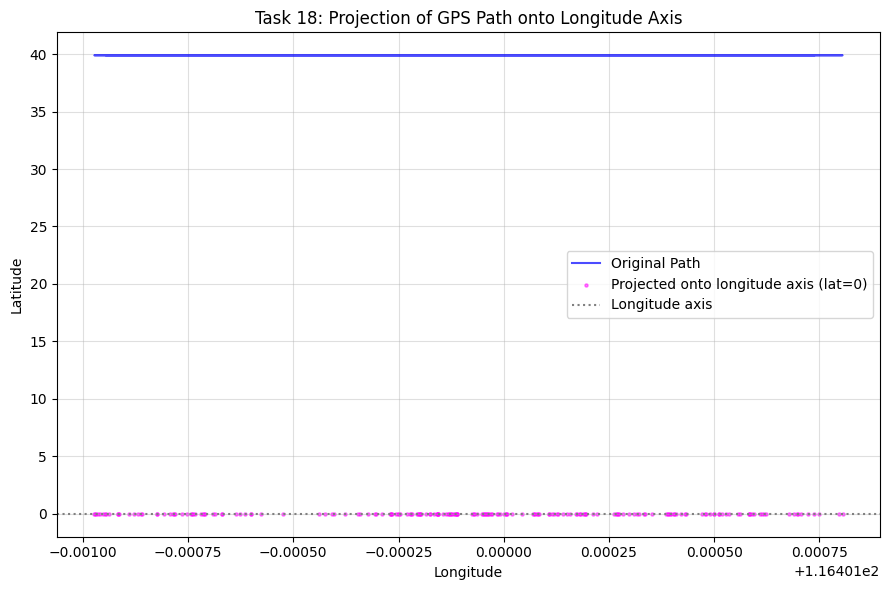

In [19]:
# ============================================================
# TASK 18: Project the path onto the longitude axis
# ============================================================

# Projection onto longitude (x) axis: keep x, set y (latitude) = 0
Proj_lon = np.array([[1, 0],
                      [0, 0]])

gps_proj_lon = Proj_lon @ gps_2d

print('Projection Matrix (onto longitude axis):')
print(Proj_lon)

plt.figure(figsize=(9, 6))
plt.plot(gps_2d[0], gps_2d[1], 'b-', linewidth=1.5, alpha=0.7, label='Original Path')
plt.scatter(gps_proj_lon[0], gps_proj_lon[1], color='magenta', s=5, alpha=0.5,
            label='Projected onto longitude axis (lat=0)')
plt.axhline(y=0, color='gray', linestyle=':', label='Longitude axis')
plt.title('Task 18: Projection of GPS Path onto Longitude Axis')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

TASK 19: INTERPRETATION OF GEOMETRIC EFFECTS ON GPS PATHS

1. TRANSLATION:
   Effect: Shifts the entire path by a fixed offset in
   longitude and/or latitude. The shape and direction
   of movement are preserved — only position changes.
   Real-world analogy: Relocating a route to a different
   part of the city.

2. ROTATION:
   Effect: Rotates the path around a pivot (centroid).
   Distances between points are preserved but direction
   of travel changes. Simulates heading change.

3. REFLECTION (x-axis):
   Effect: Mirrors the path — latitude values are negated.
   Like flipping the route from north to south hemisphere.

4. SHEARING:
   Effect: Slants the path in one direction. Simulates
   a systematic drift or directional distortion (e.g.,
   sensor bias, wind drift in aerial surveys).

5. PROJECTION (longitude axis):
   Effect: Collapses all latitude info — the path is
   flattened onto the longitude axis. Useful for studying
   east-west displacement only.


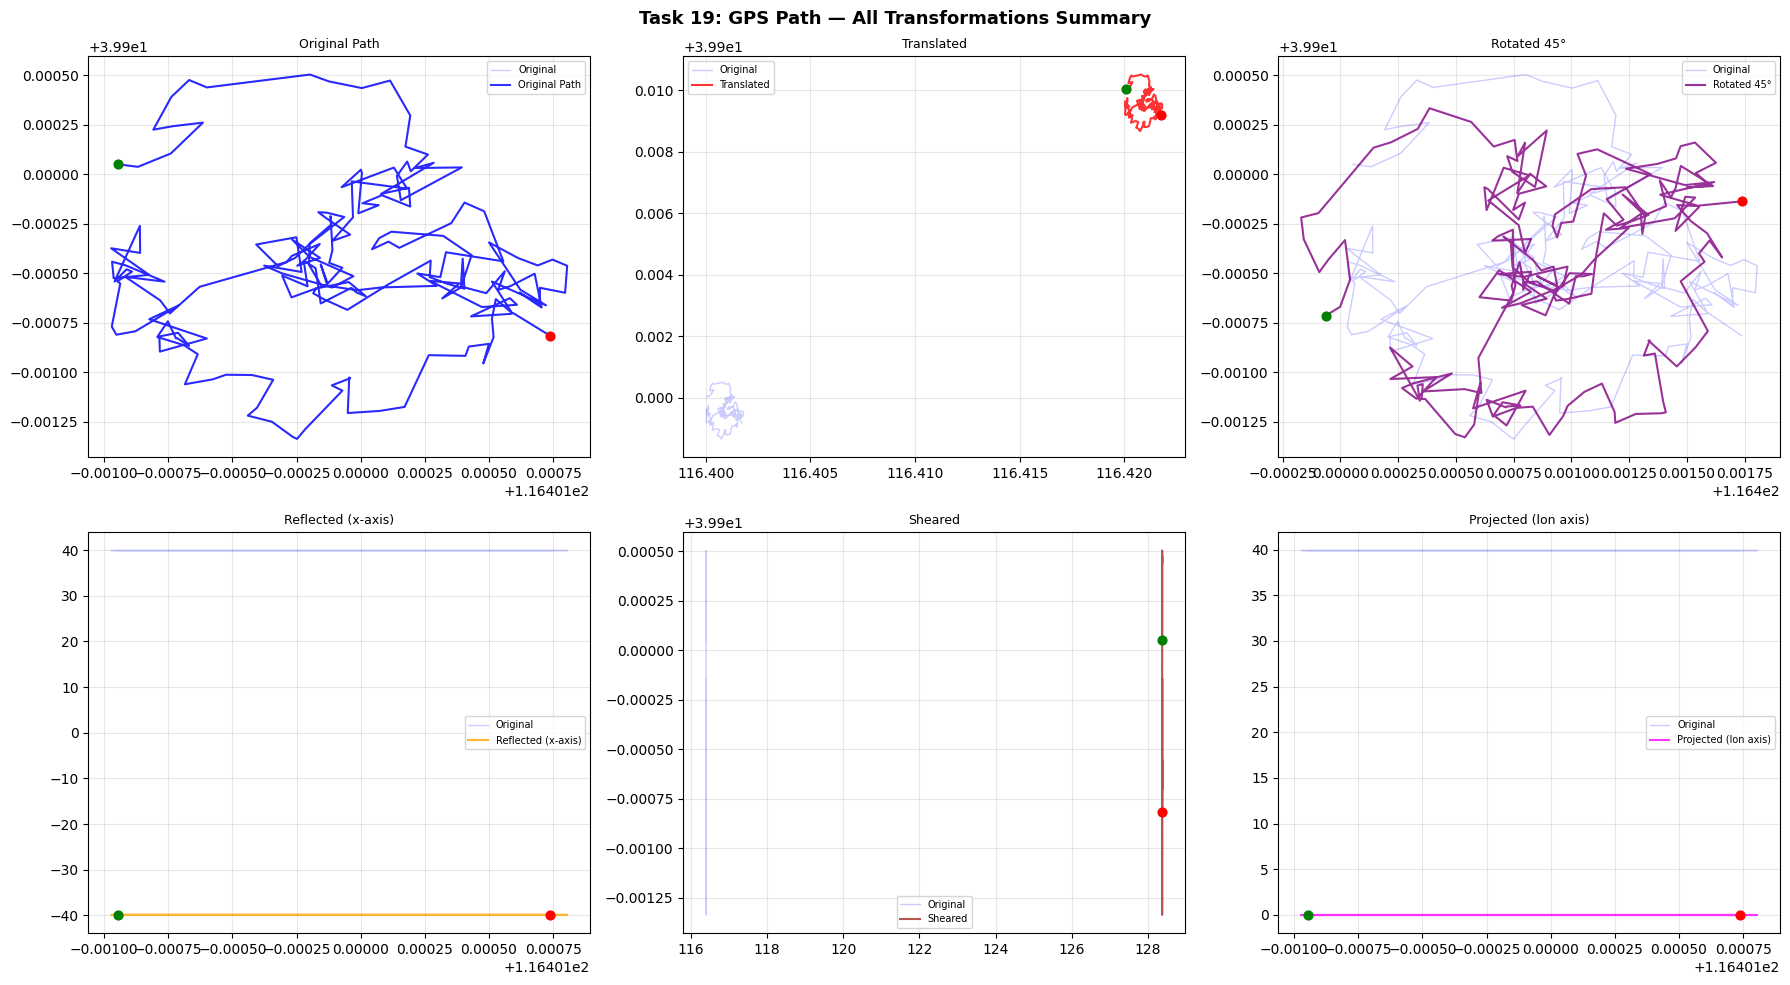

In [20]:
# ============================================================
# TASK 19: Interpret the geometric effect on movement paths
# ============================================================

print('=' * 60)
print('TASK 19: INTERPRETATION OF GEOMETRIC EFFECTS ON GPS PATHS')
print('=' * 60)
print()
print('1. TRANSLATION:')
print('   Effect: Shifts the entire path by a fixed offset in')
print('   longitude and/or latitude. The shape and direction')
print('   of movement are preserved — only position changes.')
print('   Real-world analogy: Relocating a route to a different')
print('   part of the city.')
print()
print('2. ROTATION:')
print('   Effect: Rotates the path around a pivot (centroid).')
print('   Distances between points are preserved but direction')
print('   of travel changes. Simulates heading change.')
print()
print('3. REFLECTION (x-axis):')
print('   Effect: Mirrors the path — latitude values are negated.')
print('   Like flipping the route from north to south hemisphere.')
print()
print('4. SHEARING:')
print('   Effect: Slants the path in one direction. Simulates')
print('   a systematic drift or directional distortion (e.g.,')
print('   sensor bias, wind drift in aerial surveys).')
print()
print('5. PROJECTION (longitude axis):')
print('   Effect: Collapses all latitude info — the path is')
print('   flattened onto the longitude axis. Useful for studying')
print('   east-west displacement only.')

# Visual summary: all GPS transforms in one figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Task 19: GPS Path — All Transformations Summary', fontsize=13, fontweight='bold')

gps_transforms = [
    (gps_2d,          'blue',    'Original Path'),
    (gps_translated,  'red',     'Translated'),
    (gps_rotated,     'purple',  'Rotated 45°'),
    (gps_reflected,   'orange',  'Reflected (x-axis)'),
    (gps_sheared,     'brown',   'Sheared'),
    (gps_proj_lon,    'magenta', 'Projected (lon axis)'),
]

for ax, (pts, color, title) in zip(axes.flatten(), gps_transforms):
    ax.plot(gps_2d[0], gps_2d[1], 'b-', alpha=0.2, linewidth=1, label='Original')
    ax.plot(pts[0], pts[1], color=color, linewidth=1.5, alpha=0.8, label=title)
    ax.scatter(pts[0, 0],  pts[1, 0],  color='green', s=40, zorder=5)
    ax.scatter(pts[0, -1], pts[1, -1], color='red',   s=40, zorder=5)
    ax.set_title(title, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

---
## PART C: 3D Human Movement Path

In [21]:
# ============================================================
# TASK 20: Include altitude to form 3D coordinates
# ============================================================

# Combine longitude, latitude, altitude into a 3 x N matrix
gps_3d = np.vstack([gps_lon, gps_lat, gps_alt])  # 3 x N

# Homogeneous form: 4 x N
gps_3d_h = np.vstack([gps_3d, np.ones((1, gps_3d.shape[1]))])

print('3D GPS coordinate matrix shape:', gps_3d.shape)
print('Rows: [longitude, latitude, altitude]')
print()
print('First 5 3D points:')
for i in range(5):
    print(f'  Point {i+1}: lon={gps_3d[0,i]:.6f}, lat={gps_3d[1,i]:.6f}, alt={gps_3d[2,i]:.2f}m')

3D GPS coordinate matrix shape: (3, 200)
Rows: [longitude, latitude, altitude]

First 5 3D points:
  Point 1: lon=116.400056, lat=39.900050, alt=46.81m
  Point 2: lon=116.400132, lat=39.900037, alt=49.43m
  Point 3: lon=116.400260, lat=39.900104, alt=51.27m
  Point 4: lon=116.400385, lat=39.900260, alt=51.98m
  Point 5: lon=116.400267, lat=39.900242, alt=51.60m


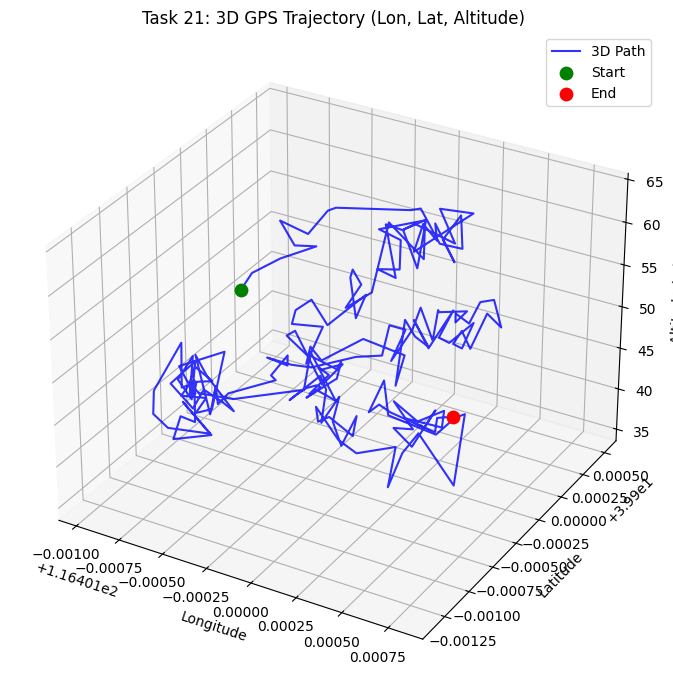

In [22]:
# ============================================================
# TASK 21: Plot the trajectory in 3D
# ============================================================

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(gps_3d[0], gps_3d[1], gps_3d[2], 'b-', linewidth=1.5, alpha=0.8, label='3D Path')
ax.scatter(gps_3d[0, 0],  gps_3d[1, 0],  gps_3d[2, 0],  color='green', s=80, zorder=5, label='Start')
ax.scatter(gps_3d[0, -1], gps_3d[1, -1], gps_3d[2, -1], color='red',   s=80, zorder=5, label='End')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude (m)')
ax.set_title('Task 21: 3D GPS Trajectory (Lon, Lat, Altitude)')
ax.legend()
plt.tight_layout(); plt.show()

3D Translation: lon+0.01, lat+0.005, alt+20m
Translation Matrix:
[[1.e+00 0.e+00 0.e+00 1.e-02]
 [0.e+00 1.e+00 0.e+00 5.e-03]
 [0.e+00 0.e+00 1.e+00 2.e+01]
 [0.e+00 0.e+00 0.e+00 1.e+00]]


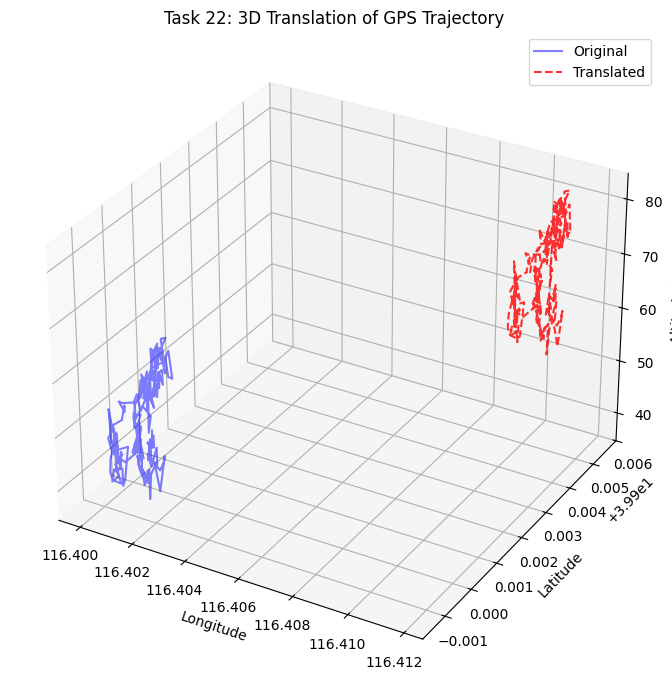

In [23]:
# ============================================================
# TASK 22: Apply translation transformation (3D)
# ============================================================

# Shift: lon+0.01, lat+0.005, alt+20m
tx3, ty3, tz3 = 0.01, 0.005, 20

T3_trans = np.array([[1, 0, 0, tx3],
                      [0, 1, 0, ty3],
                      [0, 0, 1, tz3],
                      [0, 0, 0, 1  ]])

gps_3d_translated = (T3_trans @ gps_3d_h)[:3]

print(f'3D Translation: lon+{tx3}, lat+{ty3}, alt+{tz3}m')
print('Translation Matrix:')
print(T3_trans)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(gps_3d[0], gps_3d[1], gps_3d[2], 'b-', alpha=0.5, linewidth=1.5, label='Original')
ax.plot(gps_3d_translated[0], gps_3d_translated[1], gps_3d_translated[2],
        'r--', alpha=0.8, linewidth=1.5, label='Translated')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_zlabel('Altitude (m)')
ax.set_title('Task 22: 3D Translation of GPS Trajectory')
ax.legend(); plt.tight_layout(); plt.show()

Scaling (Sx=1.0, Sy=1.0, Sz=3.0) — altitude emphasized
Scale Matrix:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 3. 0.]
 [0. 0. 0. 1.]]

Original altitude range: [35.59, 63.65]
Scaled   altitude range: [106.78, 190.95]


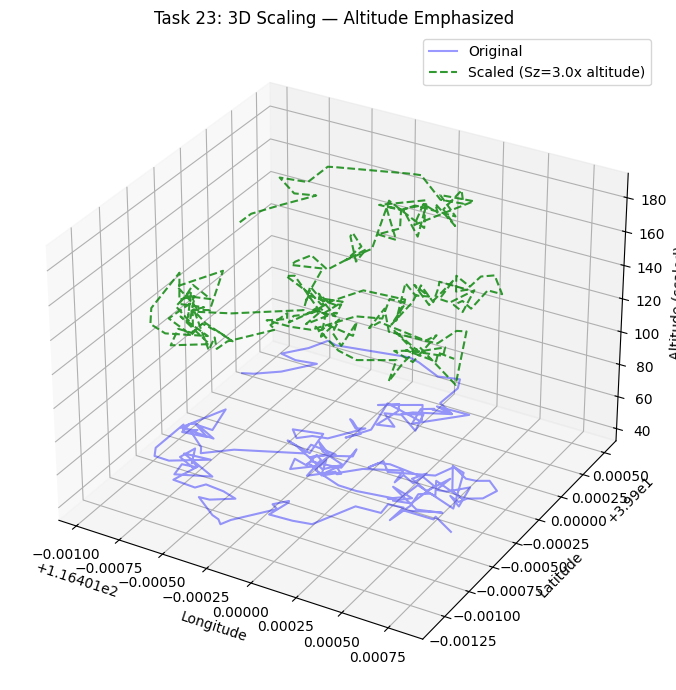

In [24]:
# ============================================================
# TASK 23: Apply scaling transformation (3D)
# ============================================================

# Scale altitude by 3x to emphasize elevation, keep lon/lat as-is
Sx3, Sy3, Sz3 = 1.0, 1.0, 3.0

T3_scale = np.array([[Sx3, 0,   0,   0],
                      [0,   Sy3, 0,   0],
                      [0,   0,   Sz3, 0],
                      [0,   0,   0,   1]])

gps_3d_scaled = (T3_scale @ gps_3d_h)[:3]

print(f'Scaling (Sx={Sx3}, Sy={Sy3}, Sz={Sz3}) — altitude emphasized')
print('Scale Matrix:')
print(T3_scale)
print(f'\nOriginal altitude range: [{gps_3d[2].min():.2f}, {gps_3d[2].max():.2f}]')
print(f'Scaled   altitude range: [{gps_3d_scaled[2].min():.2f}, {gps_3d_scaled[2].max():.2f}]')

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(gps_3d[0], gps_3d[1], gps_3d[2], 'b-', alpha=0.4, linewidth=1.5, label='Original')
ax.plot(gps_3d_scaled[0], gps_3d_scaled[1], gps_3d_scaled[2],
        'g--', alpha=0.8, linewidth=1.5, label=f'Scaled (Sz={Sz3}x altitude)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_zlabel('Altitude (scaled)')
ax.set_title('Task 23: 3D Scaling — Altitude Emphasized')
ax.legend(); plt.tight_layout(); plt.show()

Rotation Matrix (Z-axis, 45°):
[[ 0.7071 -0.7071  0.      0.    ]
 [ 0.7071  0.7071  0.      0.    ]
 [ 0.      0.      1.      0.    ]
 [ 0.      0.      0.      1.    ]]


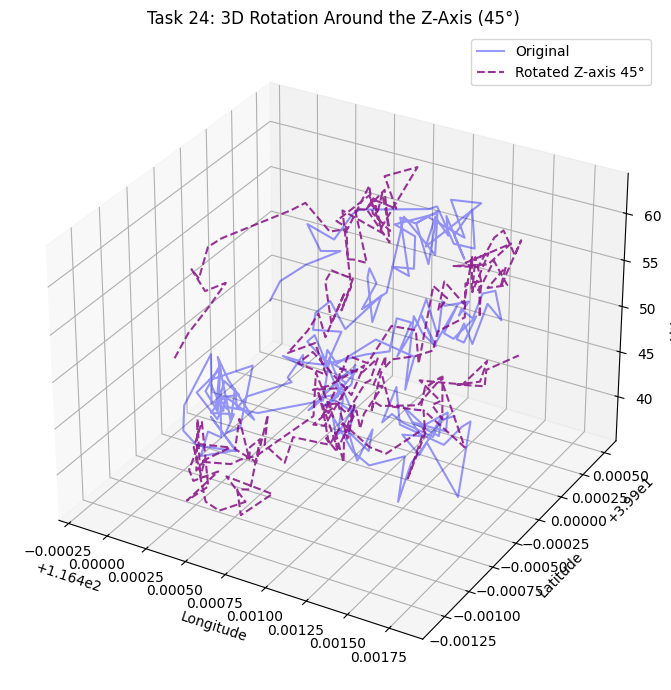

In [25]:
# ============================================================
# TASK 24: Rotate the trajectory around the Z-axis
# ============================================================

theta_z = np.radians(45)  # 45° around Z-axis

T3_rot_z = np.array([
    [np.cos(theta_z), -np.sin(theta_z), 0, 0],
    [np.sin(theta_z),  np.cos(theta_z), 0, 0],
    [0,                0,               1, 0],
    [0,                0,               0, 1]
])

# Center before rotating
centroid_3d = gps_3d.mean(axis=1, keepdims=True)
gps_3d_centered = gps_3d - centroid_3d
gps_3d_centered_h = np.vstack([gps_3d_centered, np.ones((1, gps_3d_centered.shape[1]))])

gps_3d_rotated_centered = (T3_rot_z @ gps_3d_centered_h)[:3]
gps_3d_rotated = gps_3d_rotated_centered + centroid_3d

print('Rotation Matrix (Z-axis, 45°):')
print(np.round(T3_rot_z, 4))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(gps_3d[0], gps_3d[1], gps_3d[2], 'b-', alpha=0.4, linewidth=1.5, label='Original')
ax.plot(gps_3d_rotated[0], gps_3d_rotated[1], gps_3d_rotated[2],
        color='purple', linestyle='--', alpha=0.8, linewidth=1.5, label='Rotated Z-axis 45°')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_zlabel('Altitude (m)')
ax.set_title('Task 24: 3D Rotation Around the Z-Axis (45°)')
ax.legend(); plt.tight_layout(); plt.show()

Projection Matrix (onto XY-plane, altitude=0):
[[1 0 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 0 0 1]]

All altitude values after projection: [0.]


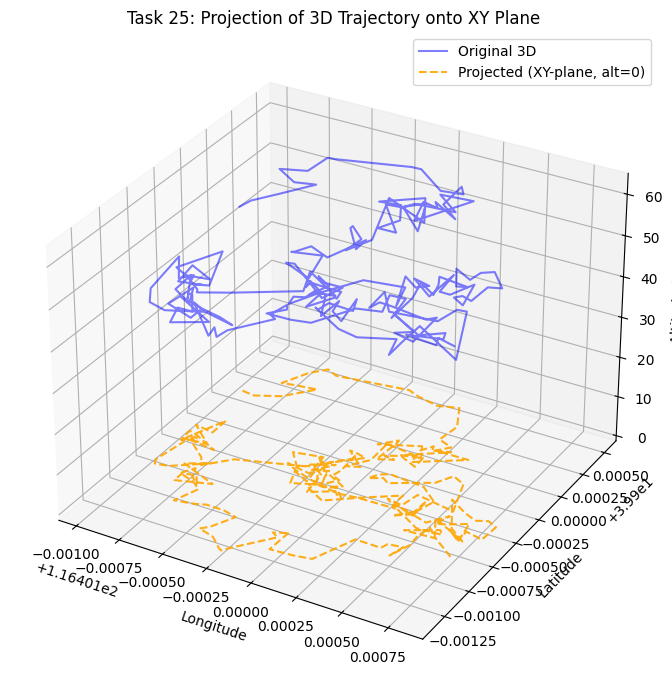

In [26]:
# ============================================================
# TASK 25: Project the path onto the XY plane
# ============================================================

# Projection onto XY-plane: keep longitude and latitude, set altitude=0
T3_proj_xy = np.array([[1, 0, 0, 0],
                        [0, 1, 0, 0],
                        [0, 0, 0, 0],
                        [0, 0, 0, 1]])

gps_3d_projected = (T3_proj_xy @ gps_3d_h)[:3]

print('Projection Matrix (onto XY-plane, altitude=0):')
print(T3_proj_xy)
print(f'\nAll altitude values after projection: {np.unique(gps_3d_projected[2])}')

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(gps_3d[0], gps_3d[1], gps_3d[2], 'b-', alpha=0.5, linewidth=1.5, label='Original 3D')
ax.plot(gps_3d_projected[0], gps_3d_projected[1], gps_3d_projected[2],
        'orange', linestyle='--', alpha=0.9, linewidth=1.5, label='Projected (XY-plane, alt=0)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_zlabel('Altitude (m)')
ax.set_title('Task 25: Projection of 3D Trajectory onto XY Plane')
ax.legend(); plt.tight_layout(); plt.show()

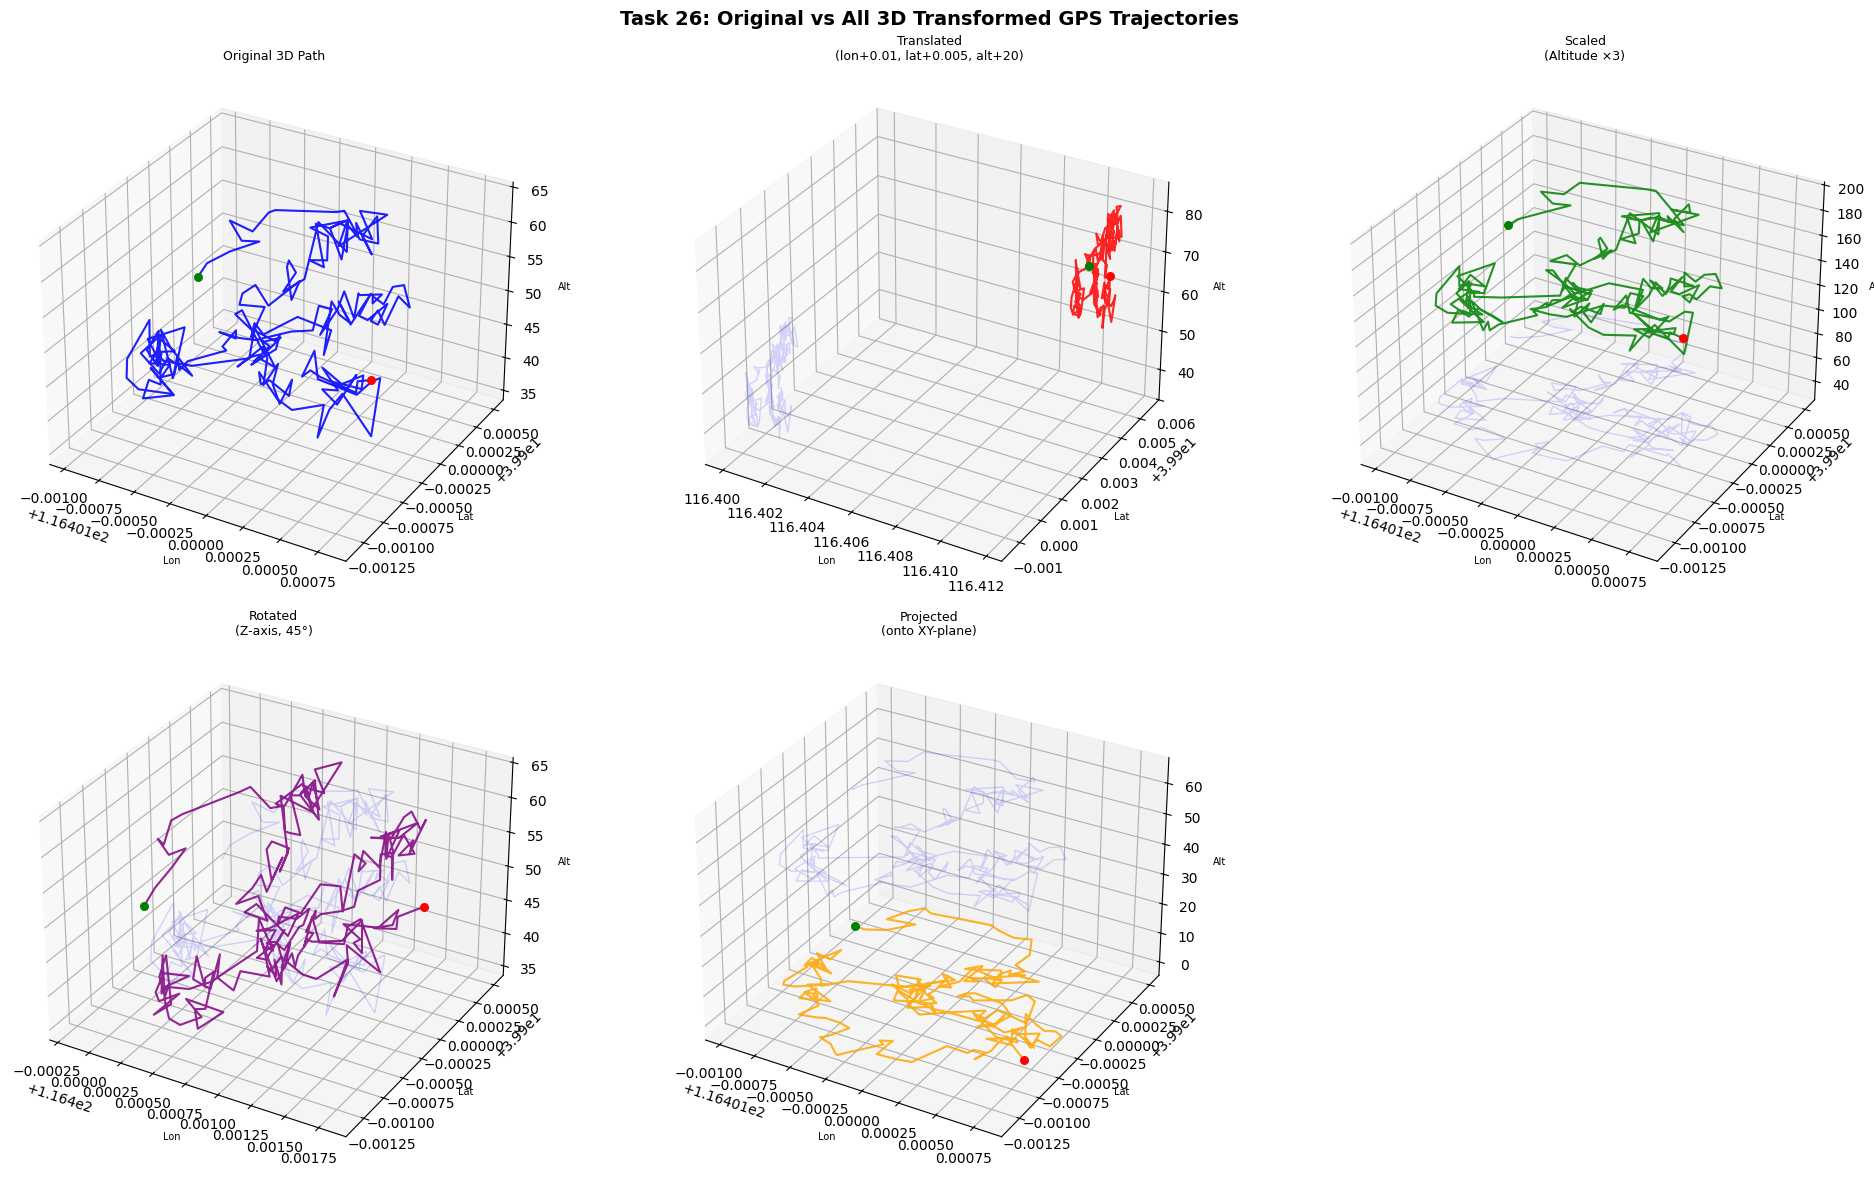


  GROUP 3 ASSIGNMENT — ALL 26 TASKS COMPLETED!
  Part A (Tasks  1-10): 2D Polygon Transformations
  Part B (Tasks 11-19): GPS Trajectory Transformations
  Part C (Tasks 20-26): 3D Human Movement Path


In [27]:
# ============================================================
# TASK 26: Compare the original and transformed trajectories
# ============================================================

fig = plt.figure(figsize=(20, 12))
fig.suptitle('Task 26: Original vs All 3D Transformed GPS Trajectories', fontsize=14, fontweight='bold')

all_3d = [
    (gps_3d,              'blue',   'Original 3D Path'),
    (gps_3d_translated,   'red',    'Translated\n(lon+0.01, lat+0.005, alt+20)'),
    (gps_3d_scaled,       'green',  'Scaled\n(Altitude ×3)'),
    (gps_3d_rotated,      'purple', 'Rotated\n(Z-axis, 45°)'),
    (gps_3d_projected,    'orange', 'Projected\n(onto XY-plane)'),
]

for i, (pts, color, title) in enumerate(all_3d):
    ax = fig.add_subplot(2, 3, i+1, projection='3d')
    # Ghost original
    ax.plot(gps_3d[0], gps_3d[1], gps_3d[2], 'b-', alpha=0.15, linewidth=1)
    # Transformed
    ax.plot(pts[0], pts[1], pts[2], color=color, linewidth=1.5, alpha=0.85)
    ax.scatter(pts[0, 0],  pts[1, 0],  pts[2, 0],  color='green', s=30, zorder=5)
    ax.scatter(pts[0, -1], pts[1, -1], pts[2, -1], color='red',   s=30, zorder=5)
    ax.set_xlabel('Lon', fontsize=7)
    ax.set_ylabel('Lat', fontsize=7)
    ax.set_zlabel('Alt', fontsize=7)
    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.show()

print()
print('=' * 55)
print('  GROUP 3 ASSIGNMENT — ALL 26 TASKS COMPLETED!')
print('=' * 55)
print('  Part A (Tasks  1-10): 2D Polygon Transformations')
print('  Part B (Tasks 11-19): GPS Trajectory Transformations')
print('  Part C (Tasks 20-26): 3D Human Movement Path')
print('=' * 55)